# 1. Load modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
import matplotlib.ticker as ticker
from scipy import optimize
import os, sys
from pathlib import Path
import xrdpy

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
print(f'xrdpy version: {xrdpy.__version__}')
print(f'xrdpy path: {xrdpy.__path__}')

xrdpy version: 0.0.7.dev0+ga5e96a3e5.d20260204
xrdpy path: ['/local/MyGitHub/xrdpy/xrdpy']


# 2. Set up default settings

## 2.1. Set xrd files path

In [4]:
xrdpy_test_path = Path().absolute()
xrd_filepath = os.path.join(xrdpy_test_path,"xrd_files")
save_fig_path = os.path.join(xrdpy_test_path,"../imgs")

## 2.2. Initialize xrd functions

In [5]:
gen_fns = xrdpy.general_fns(print_log='low')
xrd_ = xrdpy.xrd(print_log='low')
xrd_plt = xrdpy.plottings(save_figure_dir=save_fig_path, print_log='low')

## 2.3. Set matplotlib settings

In [6]:
savefig = True
color_map = 'jet'
fig_format = 'png'
fig_dpi = 75

In [7]:
color_bar_in = 'log'

xlabel_text_real_space = r'2$\mathrm{\theta}$'
ylabel_text_real_space = r'$\omega$ / $2\theta$'

# reciprocal axes are multiplited by this number to make enlarge axes
mul_fact = [10000, 10000] # along [Qx, Qy]
xlabel_text_rsm = f'$Q_x \\times $ {mul_fact[0]} (rlu)'
ylabel_text_rsm = f'$Q_z \\times $ {mul_fact[1]} (rlu)'

zlabel_text = 'Intensity (counts/s)'

# 3. Set default variables

#### Variable source: https://www.ioffe.ru/SVA/NSM/Semicond/

In [8]:
alloy_type='ternary' 
structure_type='wz'

# Lattice parameters for AlN and GaN binaries
AlN_a, AlN_c = 3.112, 4.982
GaN_a, GaN_c = 3.189, 5.185    

# Cij parameters for AlN and GaN binaries
GaN_C13 = 106
GaN_C33 = 398
AlN_C13 = 108
AlN_C33 = 373

# Bowing parameters
bowing_a = 0.0
bowing_c = 0.0
bowing_C13 = 0.0
bowing_C33 = 0.0

# a_lp_bin: [a_lattice_parameter bin_1, a_lattice_parameter bin_2, bowing]
# For ternary_wz we need followings: [a_lp_bin, c_lp_bin, c13_bin, c33_bin]
# Alloy_params = x*list_binary_parameters[i][0] + (1-x)*list_binary_parameters[i][1]+bowing*x*1-x
# WARNING: Maintain the order of data given for material parameters for all list below. 
# E.g. Do not do like [[AlN_data, GaN_data, bowing],[GaN_data, AlN_data, bowing],...]
list_binary_parameters = [[AlN_a, GaN_a, bowing_a], [AlN_c, GaN_c, bowing_c],
                          [AlN_C13, GaN_C13, bowing_C13], [AlN_C33, GaN_C33, bowing_C33]]

# Part-1: Single xrd file read and plot

## P1.1. Read xrd file

In [9]:
# Pass filename without .xml or similar. Only the name, without extensions. 
filename = "NT3334C_RSM_w2T-2T-105AlN-AlGaN_fast"
xrd_file = os.path.join(xrd_filepath, filename)

### P1.1.1 Real space data

In [10]:
# You only need this if you want to analyse real space data
two_theta_values, omega_values, intesity_values  = \
    xrd_.xrd_read_file(xrd_file_name=xrd_file,xrd_file_fmt = 'xrdml', 
                       xrd_scan_mode='omega_2theta_scan',
                       read_file_mode="omega_2theta_space_map", 
                       shift=[0,0], mul_fact_xy_axis=[1,1])

Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds


### P1.1.2 Reciprocal space data

In [11]:
rec_space_x, rec_space_y, rsm_intesity = \
    xrd_.xrd_read_file(xrd_file,xrd_file_fmt = 'xrdml', 
                       xrd_scan_mode='omega_2theta_scan', 
                       read_file_mode="reciprocal_space_map",
                       mul_fact_xy_axis=mul_fact)

Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds


## P1.2. Plottings

### P1.2.1 Real space map

In [12]:
print('Plotting real space map ...')
save_file_name = f'real_space.{fig_format}' if savefig else None

_ = xrd_.xrd_plot(save_figure_dir=save_fig_path, save_file_name=save_file_name, 
                  mode="omega_2theta_space_map", threshold_intensity=0.001,
                  xaxis_label=xlabel_text_real_space,
                  yaxis_label=ylabel_text_real_space, 
                  color_map=color_map, color_scale=color_bar_in, 
                  show_contours=True, contour_levels=None,
                  colorbar_label=zlabel_text, show_plot=True, 
                  savefig=savefig, dpi=fig_dpi)

Plotting real space map ...


### P1.2.2 Reciprocal space map 

**NOTE:** One can use xrd_plot() function **either** from xrd class **or** plottings class. For plottings class xrd_plot() call you have to pass the
x, y, and z values; whereas if it is called from xrd class we do not need to pass x, y, z argument. They are already saved internally.

#### P1.2.2.1 Using xrd_plot inherent to xrd class

In [13]:
print('Plotting reciprocal space map (without any shift)...')
save_file_name = f'reciprocal_space.{fig_format}' if savefig else None

_ = xrd_.xrd_plot(save_figure_dir=save_fig_path, save_file_name=save_file_name, 
                  mode="reciprocal_space_map", threshold_intensity=1e-5,
                  xaxis_label=xlabel_text_rsm, yaxis_label=ylabel_text_rsm, 
                  color_map=color_map, color_scale=color_bar_in,
                  colorbar_label=zlabel_text, 
                  show_contours=True,contour_levels=None,
                  show_plot=True, savefig=savefig, dpi=fig_dpi)

Plotting reciprocal space map (without any shift)...


#### P1.2.2.2 Using xrd_plot from plottings class

In [14]:
print('Plotting reciprocal space map (without any shift)...')
save_file_name = f'reciprocal_space.{fig_format}' if savefig else None

_ = xrd_plt.xrd_plot(save_file_name=save_file_name, x_values=rec_space_x, 
                     y_values=rec_space_y, z_values=rsm_intesity,
                     mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm, 
                     yaxis_label=ylabel_text_rsm, threshold_intensity=0.1, 
                     color_map=color_map, color_scale=color_bar_in,
                     colorbar_label=zlabel_text, show_contours=True,
                     contour_levels=9, savefig=savefig, dpi=fig_dpi)

Plotting reciprocal space map (without any shift)...


# Part-3: Peak finding in xrd plot

## P3.1. Example-1: Multiple peaks detection 

### P3.1.1 Read xrd files (only reading reciprocal space)

In [15]:
# Pass filename without .xml or similar. Only the name, without extensions. 
filename = "NT3285_RSM_w-2T_105AlGaN_calibration_fine"
xrd_file = os.path.join(xrd_filepath, filename)

In [16]:
rec_space_x, rec_space_y, rsm_intesity = \
    xrd_.xrd_read_file(xrd_file_name=xrd_file, 
                       read_file_mode="reciprocal_space_map", 
                       mul_fact_xy_axis=mul_fact)

Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds


### P3.1.2 Find peaks 

**NOTE:** You have to play with threshold and sigma value for finding all peaks. Need enough threshold to get-rid-of low intensity peaks,
otherwise a lot of local peaks will be detected. Sigma then applies smoothening on the noise filtered image to simplify the peak detection. 
See, the line scan figure below for details.

In [17]:
peaks_x, peaks_y, peaks_z, _ = xrd_.find_peaks(rec_space_x, rec_space_y, rsm_intesity,
                                               apply_filter=True, threshold=100,
                                               sigma=1, filter_type='gaussian')
for ii in range(len(peaks_x)):
    print(f'Intensity at [{peaks_x[ii]:0.2f}, {peaks_y[ii]:0.2f}] = {peaks_z[ii]:0.2f}')

Intensity at [3770.71, 9850.99] = 1962.77
Intensity at [3772.79, 9897.31] = 2012.84
Intensity at [3773.62, 9914.89] = 2103.98
Intensity at [3774.66, 9946.02] = 1775.35
Intensity at [3775.94, 9957.15] = 1801.03
Intensity at [3775.33, 9973.71] = 1708.60
Intensity at [3776.83, 10006.34] = 344.03
Intensity at [3776.74, 10019.18] = 3379.97


### P3.1.3. Plottings

In [18]:
save_file_name = f'detect_peaks.{fig_format}' if savefig else None

fig, ax, _ = xrd_plt.xrd_plot(save_file_name=save_file_name, x_values=rec_space_x, 
                              y_values=rec_space_y, z_values=rsm_intesity,
                              mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm, 
                              yaxis_label=ylabel_text_rsm, threshold_intensity=1, 
                              color_map=color_map, color_scale=color_bar_in,
                              colorbar_label=zlabel_text, show_contours=True, 
                              show_plot=False)
#====================== Add peaks ========================
for ii, (xi, yi) in enumerate(zip(peaks_x, peaks_y)):
    ax.annotate(str(ii+1), (xi, yi), xytext=(6,0), 
                textcoords='offset points', fontsize=10, color='k')
    
ax.scatter(peaks_x, peaks_y, marker='x', color='k')

if savefig:
    xrd_plt.save_figure(save_file_name, fig=fig, dpi=fig_dpi)
    plt.close()

## P3.2. Example-2: Sensitive peaks detection 

### P3.2.1 Read xrd files (only reading reciprocal space)

In [19]:
# Pass filename without .xml or similar. Only the name, without extensions. 
filename = "Samp3_RSM-w2T-2T_105"
xrd_file = os.path.join(xrd_filepath, filename)

In [20]:
rec_space_x, rec_space_y, rsm_intesity = \
    xrd_.xrd_read_file(xrd_file_name=xrd_file, read_file_mode="reciprocal_space_map", 
                       mul_fact_xy_axis=mul_fact)

Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds


### P3.2.2 Find peaks 

**NOTE:** Since, in this case, some peaks are very faint you have to play with threshold and sigma value. Here, we
Need low enough threshold to detect the low intensity peaks. But too  low threshold will detect again a lot of 
local low intensity peaks. Too low sigma again would pick up a lot of peaks. You need enough sigma
to filter out the noise. See, the line scan figure below.

In [21]:
peaks_x, peaks_y, peaks_z, rsm_intesity_filter = xrd_.find_peaks(rec_space_x, rec_space_y, rsm_intesity,
                                                                 apply_filter=True, threshold=10,
                                                                 sigma=5, filter_type='gaussian')
for ii in range(len(peaks_x)):
    print(f'Intensity at [{peaks_x[ii]:0.2f}, {peaks_y[ii]:0.2f}] = {peaks_z[ii]:0.2f}')

Intensity at [3569.41, 9491.46] = 12.97
Intensity at [3533.28, 9512.26] = 11.45
Intensity at [3584.17, 9651.82] = 15476.61


### P3.3.3. Plottings

In [22]:
save_file_name = f'sensitive_peaks.{fig_format}' if savefig else None
#====================== Plot the map =================================
fig, axs = plt.subplots(1, 2, figsize=(14,6), constrained_layout=True)
fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs[0], save_file_name=None, 
                              x_values=rec_space_x, y_values=rec_space_y, z_values=rsm_intesity,
                              mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm, 
                              yaxis_label=ylabel_text_rsm, threshold_intensity=10, 
                              color_map=color_map, color_scale=color_bar_in,
                              colorbar_label=zlabel_text, show_contours=True,
                              show_plot=False)
#====================== Add peaks ========================
axs[0].scatter(peaks_x, peaks_y, marker='x', color='k')
for ii, (xi, yi) in enumerate(zip(peaks_x, peaks_y)):
    axs[0].annotate(str(ii+1), (xi, yi), xytext=(6,0), 
                    textcoords='offset points', fontsize=10, color='k')

#================= Getting line scan =======================
get_y_section=160 # integer row index : not the original data value
XX = rec_space_x[get_y_section]

axs[0].plot(XX,rec_space_y[get_y_section], c='r', ls='--', lw=2)

axs[1].plot(XX,rsm_intesity[get_y_section], c='r', ls='-', label='original')
axs[1].plot(XX,rsm_intesity_filter[get_y_section], c='b', ls='-', label='smooth')
axs[1].set_xlabel(xlabel_text_rsm)
axs[1].set_ylabel(zlabel_text)
axs[1].legend()

if savefig:
    xrd_plt.save_figure(save_file_name, fig=fig, dpi=fig_dpi)
    plt.close()

# Part-4: $\omega$ angle correction to RSM plots

In this case we perform XRD measuremets in two OMEGA-angles and correct them through rotation. The details has been presented 
in the documentation of the package.

## P4.1. Read xrd files (only reading reciprocal space)

In [23]:
# # Pass filenames without .xml or similar. Only the name, without extensions. 
sample_id = 'NT3615B'
filename_list = [f"{sample_id}_RSM_105_1", f"{sample_id}_RSM_105_2"]

### P4.1.1 Quickly plot the RSM plots to say which peaks to align

**NOTE:** When you want to plot multiple subplots but with single colorbar, make sure to set 'vmax' and 'vmin' argument which ensures color scale for both
plots are the same. Otherwise, color scale could be different for diffferent plots. If 'vmax' and 'vmin' are not set then we misinterprete the results. 

* Plotting order goes from left to right and top to bottom order
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_1
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
[3724.87044236 3750.13308017 3721.74737189] [ 9916.5307166  10007.38143026 10050.18771326]
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_2
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
[-3680.1934145  -3704.43080663 -3677.01135272] [ 9931.80473676 10023.74511884 10066.89765865]


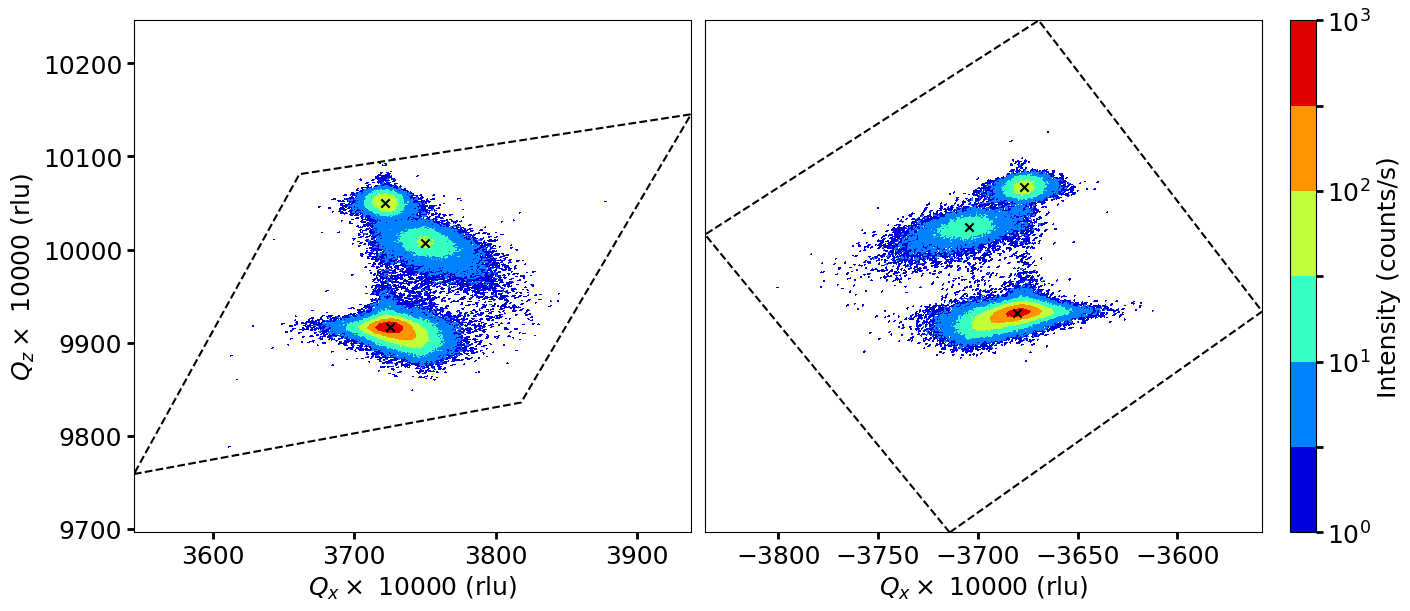

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14,6), sharey=True, sharex=False,
                    constrained_layout=True)
print('* Plotting order goes from left to right and top to bottom order')
show_colorbar = False
for ll, filename in enumerate(filename_list):
    xrd_file = os.path.join(xrd_filepath, filename)
    print(f'o Reading file: {xrd_file}')
    rec_space_x, rec_space_y, rsm_intesity = xrd_.xrd_read_file(xrd_file, 
                                                                read_file_mode="reciprocal_space_map", 
                                                                mul_fact_xy_axis=mul_fact)
    peaks_x, peaks_y, peaks_z, _ = xrd_.find_peaks(rec_space_x, rec_space_y, rsm_intesity,
                                                   apply_filter=True, threshold=15,
                                                   sigma=5, filter_type='gaussian')
    fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs[ll], save_file_name=None, 
                                 x_values=rec_space_x, y_values=rec_space_y, 
                                 z_values=rsm_intesity,mode="reciprocal_space_map", 
                                 xaxis_label=xlabel_text_rsm, yaxis_label=ylabel_text_rsm, 
                                 colorbar_label=zlabel_text, color_map=color_map, 
                                 color_scale=color_bar_in, threshold_intensity=1, 
                                 show_contours=True, vmin=1, vmax=1e3,
                                 show_colorbar=show_colorbar, show_plot=False)
    print(peaks_x, peaks_y)
    # Add the peaks
    axs[ll].scatter(peaks_x, peaks_y, marker='x', color='k')
    if ll==0: show_colorbar=True 
axs[1].yaxis.set_visible(False)

## P4.2 Align target peaks for each RSM plots

### P4.2.1 Define target peak index

**NOTE:** 'align_peaks_index' can be index of a target peak, or (x,y) position of taget peaks for the two plots 
e.g. [(x1,y1),(x2,y2)], or it can a rotation angle (in radian) you want to rotate the figure.

In [25]:
align_peaks_index = 0

### P4.2.2 Perform rotation and alignment

In [26]:
full_filenames = [os.path.join(xrd_filepath, filename) for filename in filename_list]

rec_space_data_dict = xrd_.align_peaks(full_filenames, 
                                       read_file_mode='reciprocal_space_map',
                                       peaks_2_align=align_peaks_index,mul_fact_xy_axis=
                                       mul_fact, apply_filter=True, threshold=15,
                                       sigma=5, filter_type='gaussian',
                                       return_data_4_all=True)

o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_1
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_2
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
-Distance from origin for target peak 1 = 10593.02796
-Distance from origin for target peak 1 = 10591.72172
Rotation needed: 0.002228 rad = 0.13 degree


## P4.3 Plottings

### P4.3.1 Plot rotated target peaks

In [27]:
data_org, data_rotate = [[0,0]], [[0,0]]
for file, data in rec_space_data_dict.items():
    data_org.append([data['peak_xs'][align_peaks_index], data['peak_ys'][align_peaks_index]])
    data_rotate.append([data['peaks_x_final'][align_peaks_index], data['peaks_y_final'][align_peaks_index]])
data_org.append([0,0])
data_rotate.append([0,0])
data_org, data_rotate = np.vstack(data_org), np.vstack(data_rotate)

In [28]:
fig, ax = plt.subplots()
ax.plot(data_org[:,0], data_org[:,1],'ko-', label='orginal')
ax.plot(data_rotate[:,0], data_rotate[:,1],'ro--', label='rotated')
ax.axhline(y=0, c='k', ls='--')
ax.axvline(x=0, c='k', ls='--')
ax.set_xlabel(xlabel_text_rsm)
ax.set_ylabel(ylabel_text_rsm)
ax.legend()

xrd_plt.save_figure('rotation_refence_peak.png', fig=fig, savefig=savefig)

### P4.3.2 Plot after before and after omega rotation

In [29]:
save_file_name = f'rsm_rotation.{fig_format}' if savefig else None
data = rec_space_data_dict[0]
fig, axs = plt.subplots() 
#====================== Plot-1 the map =================================
fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs, save_file_name=None, x_values=data['x_initial_sup'], 
                             y_values=data['y_initial_sup'], z_values=data['intesity_sup'],
                             mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm,
                             yaxis_label=ylabel_text_rsm, threshold_intensity=20, 
                             color_map=color_map, color_scale=color_bar_in, vmax=1e3,
                             show_colorbar=False, colorbar_label=zlabel_text, 
                             show_contours=True,show_plot=False, contour_levels=9)

axs.scatter(data['peak_xs'], data['peak_ys'], marker='x', color='k')

#====================== Plot-2 the map =================================
fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs, save_file_name=None, x_values=data['x_final'], 
                              y_values=data['y_final'], z_values=data['intesity_sup'],
                              mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm,
                              yaxis_label=ylabel_text_rsm, threshold_intensity=12, 
                              color_map=color_map, color_scale=color_bar_in,vmax=1e3,
                              colorbar_label=zlabel_text, show_contours=True,
                              show_plot=False, contour_levels=9)
axs.scatter(data['peaks_x_final'], data['peaks_y_final'], marker='x', color='k')

if savefig:
    xrd_plt.save_figure(save_file_name, fig=fig, dpi=fig_dpi)
    plt.close()

# Part-5: Strain calculation from RSM plots

TBA

# Part-6: Merge multiple xrd plots

## P6.1. Read xrd files (only reading reciprocal space)

In [30]:
# # Pass filenames without .xml or similar. Only the name, without extensions. 
filename_list = ["NT3330_RSM_w2T-2T-105AlN-AlGaN", 
                 "NT3285_RSM_w-2T_105AlGaN_calibration_fine"]
total_files_read =  len(filename_list)

In [31]:
rec_space_data = {}
for filename in filename_list:
    xrd_file = os.path.join(xrd_filepath, filename)
    print(f'o Reading file: {xrd_file}')
    rec_space_x, rec_space_y, rsm_intesity = \
        xrd_.xrd_read_file(xrd_file_name=xrd_file, 
                           read_file_mode="reciprocal_space_map", 
                           mul_fact_xy_axis=mul_fact)
    peaks_x, peaks_y, peaks_z, _ = xrd_.find_peaks(rec_space_x, rec_space_y, rsm_intesity,
                                                   apply_filter=True, threshold=100,
                                                   sigma=1, filter_type='gaussian')
    rec_space_data[filename] = {'rec_space_x': rec_space_x, 
                                'rec_space_y': rec_space_y, 
                                'rsm_intesity': rsm_intesity, 
                                'peak_xs': peaks_x, 
                                'peak_ys': peaks_y, 
                                'peak_zs': peaks_z}
    print(f'{"="*70}')

o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3330_RSM_w2T-2T-105AlN-AlGaN
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3285_RSM_w-2T_105AlGaN_calibration_fine
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds


## P6.2. Plottings

### P6.2.1 Plot two reciprocal space maps side by side

In [32]:
save_file_name = f'reciprocal_space_overlay.{fig_format}' if savefig else None

#====================== Plot the map =================================
fig, axs = plt.subplots(1, 2, figsize=(14,6), sharey=True, sharex=False,
                        constrained_layout=True)
print('* Plotting order goes from left to right and top to bottom order')
show_colorbar = False
for ll, (rec_data_file, rec_data) in enumerate(rec_space_data.items()):
    print(f'- File: {rec_data_file}')
    fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs[ll], save_file_name=None, 
                                 x_values=rec_data['rec_space_x'], 
                                 y_values=rec_data['rec_space_y'], 
                                 z_values=rec_data['rsm_intesity'],
                                 mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm, 
                                 yaxis_label=ylabel_text_rsm, colorbar_label=zlabel_text, 
                                 color_map=color_map, color_scale=color_bar_in,
                                 threshold_intensity=0.9, show_contours=True, vmin=1,vmax=1e4,
                                 contour_levels=9, show_colorbar=show_colorbar, show_plot=False)
    # Add the peaks
    axs[ll].scatter(rec_data['peak_xs'], rec_data['peak_ys'], marker='x', color='k')
    if ll+2 == total_files_read: show_colorbar=True 
        
# Remove 2nd yaxis labels        
for ll in range(1, total_files_read):
    axs[ll].yaxis.set_visible(False)
    
if savefig:
    xrd_plt.save_figure(save_file_name, fig=fig, dpi=fig_dpi)
    plt.close()

* Plotting order goes from left to right and top to bottom order
- File: NT3330_RSM_w2T-2T-105AlN-AlGaN
- File: NT3285_RSM_w-2T_105AlGaN_calibration_fine


### P6.2.2 Plot two reciprocal space maps in the same plot (* not recommended)
WARNING: in this case x-axis is shifted by an amount. Be careful during interpretation.

* Plotting order goes from left to right and top to bottom order
- File: NT3330_RSM_w2T-2T-105AlN-AlGaN
- File: NT3285_RSM_w-2T_105AlGaN_calibration_fine


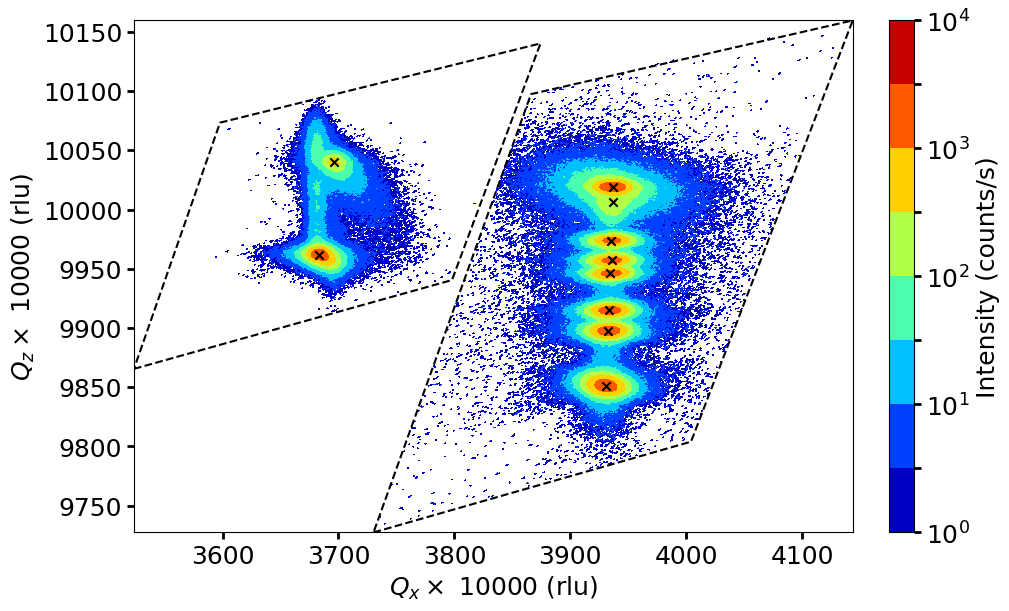

In [33]:
fig, axs = plt.subplots(1, 1, figsize=(10,6), constrained_layout=True)
print('* Plotting order goes from left to right and top to bottom order')
show_colorbar = False
shift_2nd_plot = 0
for ll, (rec_data_file, rec_data) in enumerate(rec_space_data.items()):
    print(f'- File: {rec_data_file}')
    fig, axs, _ = xrd_plt.xrd_plot(fig=fig, ax=axs, save_file_name=None, 
                                     x_values=rec_data['rec_space_x']+shift_2nd_plot, 
                                     y_values=rec_data['rec_space_y'], 
                                     z_values=rec_data['rsm_intesity'],
                                     mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm, 
                                     yaxis_label=ylabel_text_rsm, colorbar_label=zlabel_text, 
                                     color_map=color_map, color_scale=color_bar_in,
                                     threshold_intensity=0.9, vmin=1, vmax=1e4,
                                     show_contours=True, contour_levels=None, 
                                     show_colorbar=show_colorbar, show_plot=False)
    # Add the peaks
    axs.scatter(rec_data['peak_xs']+shift_2nd_plot, rec_data['peak_ys'], marker='x', color='k')
    if ll+2 == total_files_read: 
        show_colorbar=True; shift_2nd_plot=160

# Part-6: Align different RSM plots

## P6.1: Using $\omega$ rotated RSM plots 

For each sample we have **two xrd** measurements which are differ by certain rotation. 

### P6.1.1 Read xrd files (only reading reciprocal space)

In [34]:
# # Pass filenames without .xml or similar. Only the name, without extensions. 
sample_id1, sample_id2 = 'NT3615A', 'NT3615B'
filename_dict = {sample_id1: [f"{sample_id1}_RSM_105_1", f"{sample_id1}_RSM_105_2"],
                 sample_id2: [f"{sample_id2}_RSM_105_1", f"{sample_id2}_RSM_105_2"]}

### P6.1.2 Quickly plot the RSM plots to say which peaks to align

* Plotting order goes from left to right and top to bottom order
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615A_RSM_105_1
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
[3694.44831854 3695.28678452] [ 9911.93721079 10041.03261947]
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615A_RSM_105_2
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
[-3735.01280609 -3735.36647377] [ 9897.29419567 10026.32144469]
* Plotting order goes from left to right and top to bottom order
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_1
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
[3724.87044236 3750.13308017 3721.74737189] [ 9916.5307166  10007.38143026 10050.18771326]
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_2
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): coun

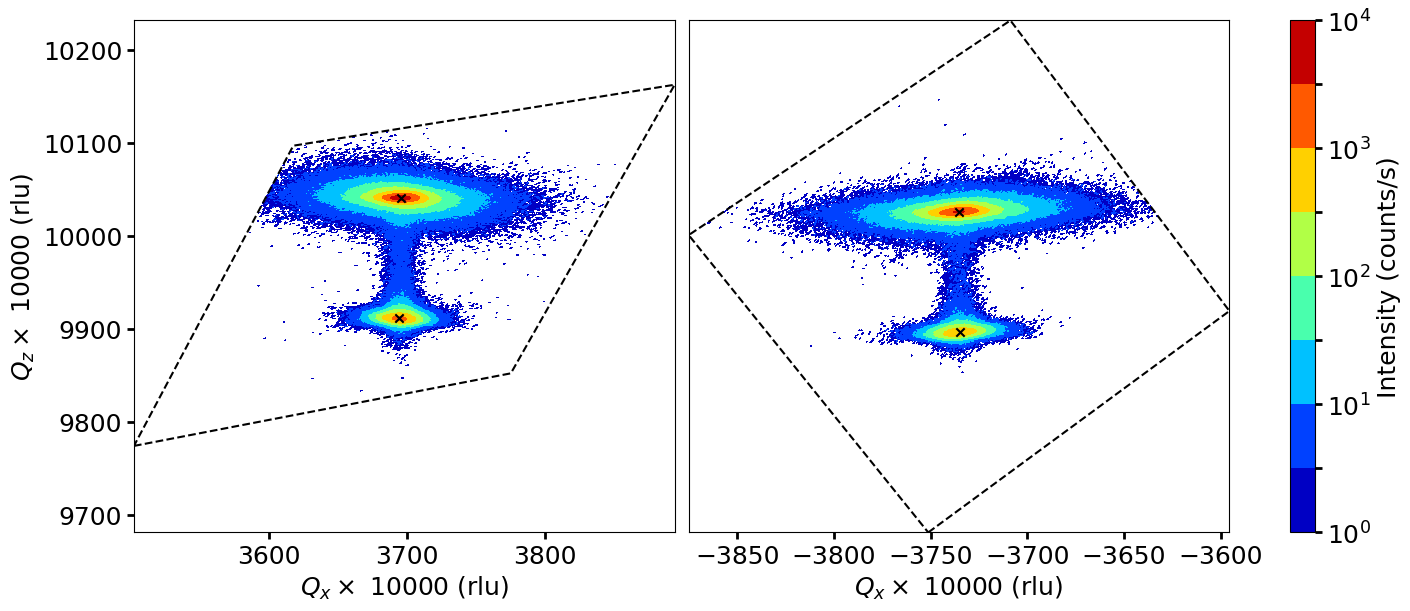

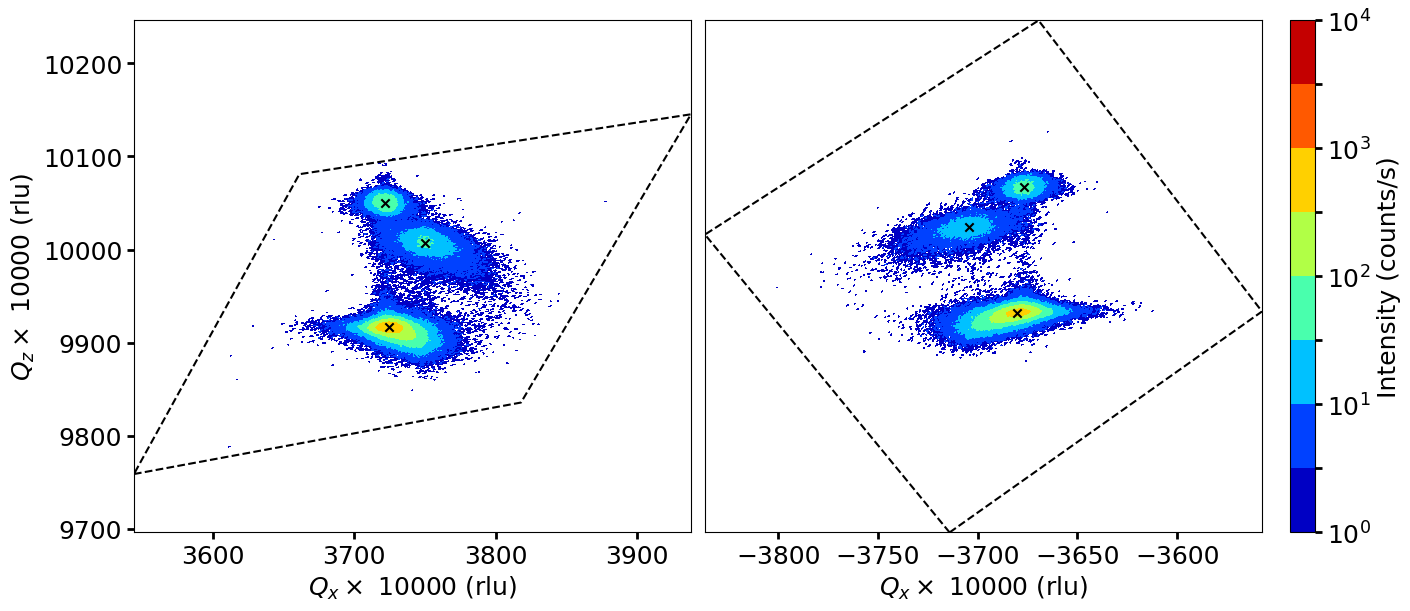

In [35]:
for sample_id, filename_list in filename_dict.items():
    fig, axs = plt.subplots(1, 2, figsize=(14,6), sharey=True, sharex=False,
                        constrained_layout=True)
    print('* Plotting order goes from left to right and top to bottom order')
    show_colorbar = False
    for ll, filename in enumerate(filename_list):
        xrd_file = os.path.join(xrd_filepath, filename)
        print(f'o Reading file: {xrd_file}')
        rec_space_x, rec_space_y, rsm_intesity = xrd_.xrd_read_file(xrd_file_name=xrd_file, 
                                                                    read_file_mode="reciprocal_space_map", 
                                                                    mul_fact_xy_axis=mul_fact)
        peaks_x, peaks_y, peaks_z, _ = xrd_.find_peaks(rec_space_x, rec_space_y, rsm_intesity,
                                                       apply_filter=True, threshold=15,
                                                       sigma=5, filter_type='gaussian')
        fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs[ll], save_file_name=None, 
                                     x_values=rec_space_x, y_values=rec_space_y, 
                                     z_values=rsm_intesity,mode="reciprocal_space_map", 
                                     xaxis_label=xlabel_text_rsm, yaxis_label=ylabel_text_rsm, 
                                     colorbar_label=zlabel_text, color_map=color_map, 
                                     color_scale=color_bar_in, threshold_intensity=1, 
                                     show_contours=True, contour_levels=None, vmin=1,vmax=1e4,
                                     show_colorbar=show_colorbar, show_plot=False)
        print(peaks_x, peaks_y)
        # Add the peaks
        axs[ll].scatter(peaks_x, peaks_y, marker='x', color='k')
        if ll+2 == 2: show_colorbar=True 
            
    # Remove 2nd yaxis labels        
    for ll in range(1, 2):
        axs[ll].yaxis.set_visible(False)

### P6.1.3 Align target peaks for each sample

In [36]:
align_peaks_index = {sample_id1: 0, sample_id2: 0}

In [37]:
rec_space_data_dict = {}
for sample_id, filename_list in filename_dict.items():
    full_filenames = [os.path.join(xrd_filepath, filename) for filename in filename_list]
    rec_space_data_dict[sample_id] = xrd_.align_peaks(full_filenames, read_file_mode='reciprocal_space_map',
                                                      peaks_2_align=align_peaks_index[sample_id],
                                                      mul_fact_xy_axis=mul_fact, apply_filter=True, 
                                                      threshold=15,sigma=5, filter_type='gaussian')

o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615A_RSM_105_1
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615A_RSM_105_2
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
-Distance from origin for target peak 1 = 10578.06446
-Distance from origin for target peak 1 = 10578.59882
Rotation needed: -0.002038 rad = -0.12 degree
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_1
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
o Reading file: /local/MyGitHub/xrdpy/tutorials/xrd_files/NT3615B_RSM_105_2
Wavelength used (from xrd file): 1.5405980
Intensity unit (from xrd file): counts/seconds
-Distance from origin for target peak 1 = 10593.02796
-Distance from origin for target peak 1 = 10591.72172
Rotation needed: 0.002228 rad = 0.13 degree


### P6.1.4 Plottings

In [38]:
save_file_name = f'rsm_rotation.{fig_format}' if savefig else None

fig, axs = plt.subplots(1, 2, figsize=(14,6), sharey=True, sharex=False,
                        constrained_layout=True)
show_colorbar = False
for ll, (sample_id_, data) in enumerate(rec_space_data_dict.items()):
    
    #====================== Plot-1 the map =================================
    fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs[ll], save_file_name=None, x_values=data['x_initial_sup'], 
                                 y_values=data['y_initial_sup'], z_values=data['intesity_sup'],
                                 mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm,
                                 yaxis_label=ylabel_text_rsm, threshold_intensity=10, 
                                 color_map=color_map, color_scale=color_bar_in,
                                 show_colorbar=False, colorbar_label=zlabel_text, 
                                 vmin=1, vmax=1e4,show_contours=True,show_plot=False)
    axs[ll].scatter(data['peak_xs'], data['peak_ys'], marker='x', color='k')
    
    #====================== Plot-2 the map =================================
    fig, _, _ = xrd_plt.xrd_plot(fig=fig, ax=axs[ll], save_file_name=None, x_values=data['x_final'], 
                                 y_values=data['y_final'], z_values=data['intesity_sup'],
                                 mode="reciprocal_space_map", xaxis_label=xlabel_text_rsm,
                                 yaxis_label=ylabel_text_rsm, threshold_intensity=10, 
                                 color_map=color_map, color_scale=color_bar_in,
                                 colorbar_label=zlabel_text, show_contours=True,
                                 vmin=1, vmax=1e4,show_colorbar=show_colorbar, show_plot=False,
                                title_text=sample_id_)
    axs[ll].scatter(data['peaks_x_final'], data['peaks_y_final'], marker='x', color='k')
    
    target_peack_after_rotation = [data['peaks_x_final'][align_peaks_index[sample_id_]],
                                   data['peaks_y_final'][align_peaks_index[sample_id_]]]
    axs[ll].axhline(target_peack_after_rotation[1], color='k', ls='--')
    print(f'x={target_peack_after_rotation[0]:0.2f}, y={target_peack_after_rotation[1]:0.2f}')
    
    if ll+2 == 2: show_colorbar=True 
    # Remove 2nd yaxis labels        
    for ll in range(1, 2):
        axs[ll].yaxis.set_visible(False)

if savefig:
    xrd_plt.save_figure(save_file_name, fig=fig, dpi=fig_dpi)
    plt.close()

x=3714.64, y=9904.39
x=3702.77, y=9924.80
